In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load MetroPT-3 dataset
file_path = r"D:\metropt+3+dataset\MetroPT3(AirCompressor).csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (1516948, 17)

Columns:
['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']


In [2]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort data chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

# Display time range
print("Start time:", df["timestamp"].min())
print("End time:", df["timestamp"].max())

# Check the first few timestamps
df[["timestamp"]].head()

Start time: 2020-02-01 00:00:00
End time: 2020-09-01 03:59:50


,timestamp
0,2020-02-01 00:00:00
1,2020-02-01 00:00:10
2,2020-02-01 00:00:19
3,2020-02-01 00:00:29
4,2020-02-01 00:00:39


In [3]:
# Documented failure periods in the MetroPT-3 dataset

failure_periods = [
    {
        "failure_id": 1,
        "start": "2020-04-18 00:00:00",
        "end": "2020-04-18 23:59:00"
    },
    {
        "failure_id": 2,
        "start": "2020-05-29 23:30:00",
        "end": "2020-05-30 06:00:00"
    },
    {
        "failure_id": 3,
        "start": "2020-06-05 10:00:00",
        "end": "2020-06-07 14:30:00"
    },
    {
        "failure_id": 4,
        "start": "2020-07-15 14:30:00",
        "end": "2020-07-15 19:00:00"
    }
]

failure_df = pd.DataFrame(failure_periods)

failure_df["start"] = pd.to_datetime(failure_df["start"])
failure_df["end"] = pd.to_datetime(failure_df["end"])

failure_df

,failure_id,start,end
0,1,2020-04-18 00:00:00,2020-04-18 23:59:00
1,2,2020-05-29 23:30:00,2020-05-30 06:00:00
2,3,2020-06-05 10:00:00,2020-06-07 14:30:00
3,4,2020-07-15 14:30:00,2020-07-15 19:00:00


In [4]:
# Count the number of observations recorded during each failure

failure_counts = []

for _, failure in failure_df.iterrows():
    count = df[
        (df["timestamp"] >= failure["start"]) &
        (df["timestamp"] <= failure["end"])
    ].shape[0]

    failure_counts.append({
        "failure_id": failure["failure_id"],
        "start": failure["start"],
        "end": failure["end"],
        "observations": count
    })

failure_counts_df = pd.DataFrame(failure_counts)

failure_counts_df

,failure_id,start,end,observations
0,1,2020-04-18 00:00:00,2020-04-18 23:59:00,8657
1,2,2020-05-29 23:30:00,2020-05-30 06:00:00,2360
2,3,2020-06-05 10:00:00,2020-06-07 14:30:00,17315
3,4,2020-07-15 14:30:00,2020-07-15 19:00:00,1622


In [5]:
# Create a 24-hour window before and after each failure

event_data = []

for _, failure in failure_df.iterrows():
    start = failure["start"] - pd.Timedelta(hours=24)
    end = failure["end"] + pd.Timedelta(hours=24)

    event_subset = df[
        (df["timestamp"] >= start) &
        (df["timestamp"] <= end)
    ].copy()

    event_subset["failure_id"] = failure["failure_id"]
    event_subset["failure_start"] = failure["start"]
    event_subset["failure_end"] = failure["end"]

    event_data.append(event_subset)

event_df = pd.concat(event_data, ignore_index=True)

print("Event data shape:", event_df.shape)
event_df.head()

Event data shape: (83815, 20)


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,failure_id,failure_start,failure_end
0,5562630,2020-04-17 00:00:05,-0.012,9.342,9.332,-0.022,9.342,61.100,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1,2020-04-18,2020-04-18 23:59:00
1,5562640,2020-04-17 00:00:15,-0.014,9.328,9.316,-0.024,9.326,60.800,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1,2020-04-18,2020-04-18 23:59:00
2,5562650,2020-04-17 00:00:25,-0.014,9.316,9.304,-0.024,9.314,60.575,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1,2020-04-18,2020-04-18 23:59:00
3,5562660,2020-04-17 00:00:34,-0.014,9.300,9.288,-0.024,9.300,60.375,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1,2020-04-18,2020-04-18 23:59:00
4,5562670,2020-04-17 00:00:44,-0.012,9.284,9.274,-0.024,9.284,60.100,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1,2020-04-18,2020-04-18 23:59:00


In [6]:
# Calculate mean sensor values during each failure

sensor_columns = [
    "TP2",
    "TP3",
    "H1",
    "DV_pressure",
    "Reservoirs",
    "Oil_temperature",
    "Motor_current",
    "COMP",
    "DV_eletric",
    "Towers",
    "MPG",
    "LPS",
    "Pressure_switch",
    "Oil_level",
    "Caudal_impulses"
]

failure_means = []

for _, failure in failure_df.iterrows():

    failure_data = df[
        (df["timestamp"] >= failure["start"]) &
        (df["timestamp"] <= failure["end"])
    ]

    means = failure_data[sensor_columns].mean()

    for sensor in sensor_columns:
        failure_means.append({
            "failure_id": failure["failure_id"],
            "sensor": sensor,
            "mean": means[sensor]
        })

failure_means_df = pd.DataFrame(failure_means)

failure_means_df.head(15)

,failure_id,sensor,mean
0,1,TP2,8.518244
1,1,TP3,8.811901
2,1,H1,0.079266
3,1,DV_pressure,1.879373
4,1,Reservoirs,8.812990
5,1,Oil_temperature,74.131125
6,1,Motor_current,5.604374
7,1,COMP,0.008201
8,1,DV_eletric,0.989488
9,1,Towers,0.501213


In [7]:
# Compare mean sensor values in the 24 hours before failure
# with the mean values during the failure

comparison_results = []

for _, failure in failure_df.iterrows():

    failure_id = failure["failure_id"]

    failure_data = df[
        (df["timestamp"] >= failure["start"]) &
        (df["timestamp"] <= failure["end"])
    ]

    before_start = failure["start"] - pd.Timedelta(hours=24)

    before_data = df[
        (df["timestamp"] >= before_start) &
        (df["timestamp"] < failure["start"])
    ]

    for sensor in sensor_columns:

        before_mean = before_data[sensor].mean()
        failure_mean = failure_data[sensor].mean()

        comparison_results.append({
            "failure_id": failure_id,
            "sensor": sensor,
            "before_mean": before_mean,
            "failure_mean": failure_mean,
            "absolute_change": failure_mean - before_mean
        })

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,failure_id,sensor,before_mean,failure_mean,absolute_change
0,1,TP2,0.194092,8.518244,8.324152
1,1,TP3,8.468162,8.811901,0.343739
2,1,H1,8.247850,0.079266,-8.168584
3,1,DV_pressure,-0.022322,1.879373,1.901696
4,1,Reservoirs,8.468139,8.812990,0.344851
5,1,Oil_temperature,50.451532,74.131125,23.679594
6,1,Motor_current,0.451152,5.604374,5.153221
7,1,COMP,0.834947,0.008201,-0.826745
8,1,DV_eletric,0.023806,0.989488,0.965683
9,1,Towers,0.846850,0.501213,-0.345637


In [8]:
# Rank sensors by the magnitude of their change during each failure

for failure_id in sorted(comparison_df["failure_id"].unique()):

    failure_changes = comparison_df[
        comparison_df["failure_id"] == failure_id
    ].copy()

    failure_changes["absolute_change_magnitude"] = (
        failure_changes["absolute_change"].abs()
    )

    failure_changes = failure_changes.sort_values(
        "absolute_change_magnitude",
        ascending=False
    )

    print(f"\nFailure {failure_id}")
    print(
        failure_changes[
            ["sensor", "before_mean", "failure_mean", "absolute_change"]
        ].to_string(index=False)
    )


Failure 1
         sensor  before_mean  failure_mean  absolute_change
Oil_temperature    50.451532     74.131125        23.679594
            TP2     0.194092      8.518244         8.324152
             H1     8.247850      0.079266        -8.168584
  Motor_current     0.451152      5.604374         5.153221
    DV_pressure    -0.022322      1.879373         1.901696
     DV_eletric     0.023806      0.989488         0.965683
           COMP     0.834947      0.008201        -0.826745
            MPG     0.834947      0.008201        -0.826745
         Towers     0.846850      0.501213        -0.345637
     Reservoirs     8.468139      8.812990         0.344851
            TP3     8.468162      8.811901         0.343739
Caudal_impulses     0.858753      0.997690         0.138937
      Oil_level     0.858753      0.997690         0.138937
Pressure_switch     0.858435      0.991683         0.133248
            LPS     0.002539      0.000000        -0.002539

Failure 2
         sensor  b

In [9]:
# Define non-overlapping time bands before each failure

bands = [
    ("24-12h", 24, 12),
    ("12-6h", 12, 6),
    ("6-3h", 6, 3),
    ("3-1h", 3, 1),
    ("1h-0h", 1, 0)
]

band_results = []

for _, failure in failure_df.iterrows():

    failure_id = failure["failure_id"]
    failure_start = failure["start"]

    for band_name, start_hours, end_hours in bands:

        window_start = failure_start - pd.Timedelta(hours=start_hours)
        window_end = failure_start - pd.Timedelta(hours=end_hours)

        window_data = df[
            (df["timestamp"] >= window_start) &
            (df["timestamp"] < window_end)
        ]

        for sensor in sensor_columns:

            band_results.append({
                "failure_id": failure_id,
                "band": band_name,
                "sensor": sensor,
                "mean": window_data[sensor].mean(),
                "std": window_data[sensor].std(),
                "observations": window_data[sensor].count()
            })

band_df = pd.DataFrame(band_results)

band_df.head(15)

,failure_id,band,sensor,mean,std,observations
0,1,24-12h,TP2,0.473321,2.057235,2720
1,1,24-12h,TP3,8.758015,0.620589,2720
2,1,24-12h,H1,8.260818,2.075370,2720
3,1,24-12h,DV_pressure,-0.020114,0.124716,2720
4,1,24-12h,Reservoirs,8.757961,0.620166,2720
5,1,24-12h,Oil_temperature,51.770092,4.786077,2720
6,1,24-12h,Motor_current,0.992452,1.847137,2720
7,1,24-12h,COMP,0.888971,0.314226,2720
8,1,24-12h,DV_eletric,0.055147,0.228309,2720
9,1,24-12h,Towers,0.916544,0.276621,2720


In [10]:
# Check how many observations are available in each pre-failure band

coverage_df = (
    band_df
    .groupby(["failure_id", "band"])["observations"]
    .max()
    .reset_index()
)

coverage_df

,failure_id,band,observations
0,1,12-6h,1791
1,1,1h-0h,298
2,1,24-12h,2720
3,1,3-1h,597
4,1,6-3h,895
5,2,12-6h,2179
6,2,1h-0h,363
7,2,24-12h,3108
8,2,3-1h,727
9,2,6-3h,1089


In [11]:
# Compare mean values of selected sensors across all pre-failure bands

selected_sensors = [
    "TP2",
    "H1",
    "Motor_current",
    "Oil_temperature",
    "DV_pressure",
    "TP3",
    "Reservoirs"
]

selected_band_df = band_df[
    band_df["sensor"].isin(selected_sensors)
].copy()

band_mean_table = selected_band_df.pivot_table(
    index=["failure_id", "band"],
    columns="sensor",
    values="mean"
)

band_mean_table

sensor             DV_pressure        H1  Motor_current  Oil_temperature  \
failure_id band                                                            
1          12-6h     -0.024000  8.238000       0.040000        49.450000   
           1h-0h     -0.024000  8.238000       0.040000        49.450000   
           24-12h    -0.020114  8.260818       0.992452        51.770092   
           3-1h      -0.024000  8.238000       0.040000        49.450000   
           6-3h      -0.024000  8.238000       0.040000        49.450000   
2          12-6h     -0.014495  7.849477       2.071308        67.263068   
           1h-0h      0.510424  6.044595       2.475468        64.675000   
           24-12h    -0.012153  7.740336       2.320466        66.922338   
           3-1h       0.010140  7.921730       1.682331        62.897146   
           6-3h      -0.016990  8.013868       1.894258        65.070845   
3          12-6h     -0.011787  8.115291       1.604317        62.093919   
           1h-0h      0.347807  6.616105       2.403430        65.338705   
           24-12h    -0.014437  8.047366       1.743227        64.507549   
           3-1h      -0.008946  7.953488       2.063012        64.811795   
           6-3h      -0.017017  7.866913       1.877013        63.448003   
4          12-6h     -0.003291  5.566958       4.519696        72.560560   
           1h-0h     -0.008727  2.580386       5.212741        78.978719   
           24-12h    -0.010016  6.517165       3.770818        70.222429   
           3-1h       0.002961  4.374452       4.767345        75.476446   
           6-3h       0.007648  5.337745       4.554193        73.681032   

sensor             Reservoirs       TP2       TP3  
failure_id band                                    
1          12-6h     8.248000 -0.018000  8.248000  
           1h-0h     8.248000 -0.018000  8.248000  
           24-12h    8.757961  0.473321  8.758015  
           3-1h      8.248000 -0.018000  8.248000  
           6-3h      8.248000 -0.018000  8.248000  
2          12-6h     9.050429  1.170354  9.049429  
           1h-0h     8.829598  2.641245  8.829554  
           24-12h    9.034185  1.273354  9.033838  
           3-1h      8.990072  1.043653  8.989769  
           6-3h      9.004961  0.945719  9.004615  
3          12-6h     9.007550  0.849643  9.008046  
           1h-0h     8.980887  2.254815  8.980419  
           24-12h    9.015041  0.927866  9.014508  
           3-1h      9.145078  1.121216  9.145477  
           6-3h      8.960887  1.017499  8.961436  
4          12-6h     9.091501  3.533239  9.090157  
           1h-0h     9.297124  6.798909  9.298187  
           24-12h    9.063450  2.517691  9.061982  
           3-1h      9.166884  4.817691  9.166008  
           6-3h      9.128483  3.781727  9.126868

In [12]:
# Calculate change from the earliest pre-failure band
# (24-12h) to the final pre-failure band (1h-0h)

early = band_df[
    band_df["band"] == "24-12h"
][["failure_id", "sensor", "mean"]].rename(
    columns={"mean": "early_mean"}
)

late = band_df[
    band_df["band"] == "1h-0h"
][["failure_id", "sensor", "mean"]].rename(
    columns={"mean": "late_mean"}
)

sensor_changes = early.merge(
    late,
    on=["failure_id", "sensor"]
)

sensor_changes["absolute_change"] = (
    sensor_changes["late_mean"] -
    sensor_changes["early_mean"]
)

sensor_changes["percent_change"] = (
    sensor_changes["absolute_change"] /
    sensor_changes["early_mean"].abs()
) * 100

sensor_changes.sort_values(
    ["sensor", "failure_id"]
)

,failure_id,sensor,early_mean,late_mean,absolute_change,percent_change
7,1,COMP,0.888971,0.778523,-0.110447,-12.424157
22,2,COMP,0.859717,0.677686,-0.182031,-21.173356
37,3,COMP,0.895365,0.735537,-0.159828,-17.850562
52,4,COMP,0.721007,0.283747,-0.437260,-60.645774
14,1,Caudal_impulses,0.944118,0.778523,-0.165594,-17.539568
29,2,Caudal_impulses,1.000000,1.000000,0.000000,0.000000
44,3,Caudal_impulses,1.000000,1.000000,0.000000,0.000000
59,4,Caudal_impulses,1.000000,1.000000,0.000000,0.000000
8,1,DV_eletric,0.055147,0.000000,-0.055147,-100.000000
23,2,DV_eletric,0.140605,0.322314,0.181709,129.233882


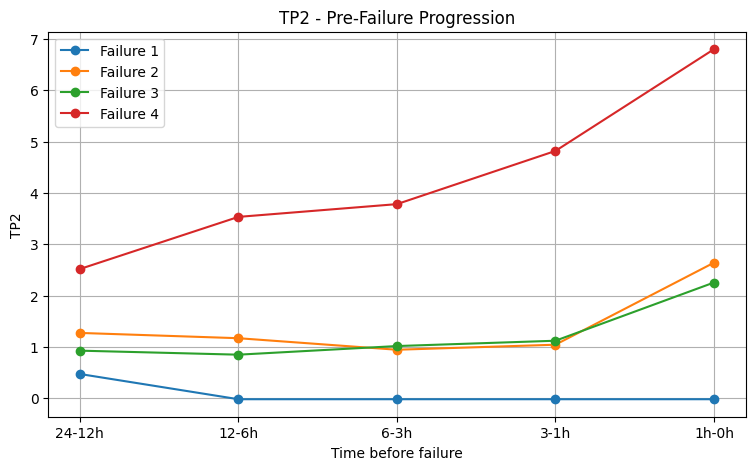

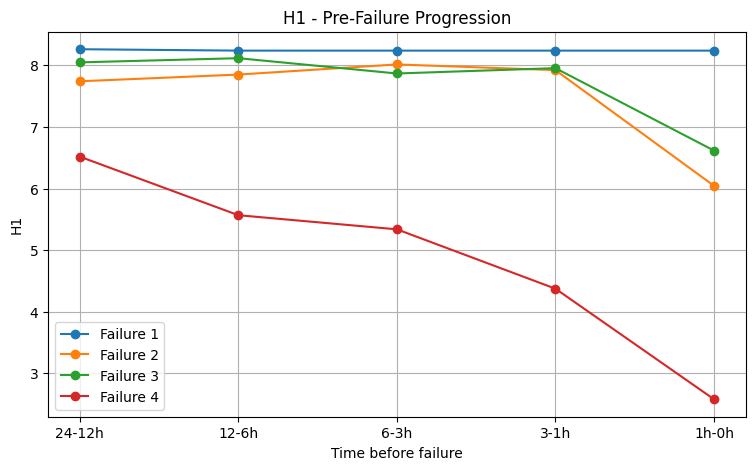

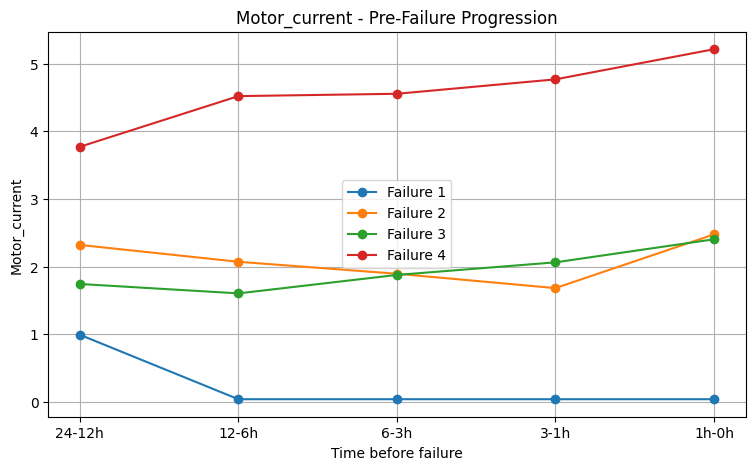

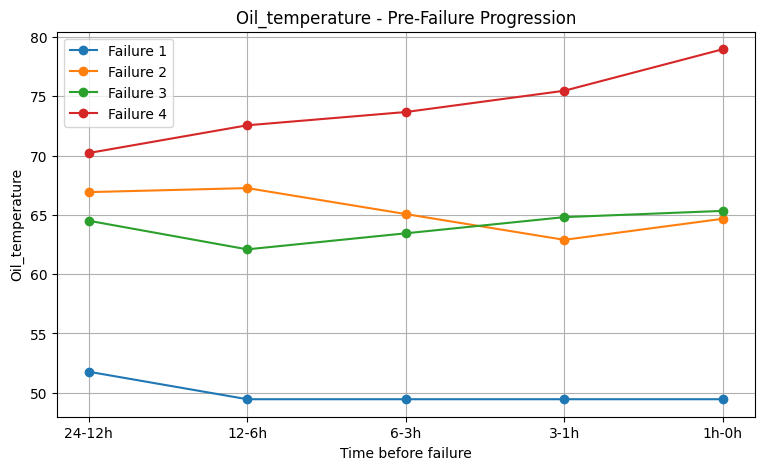

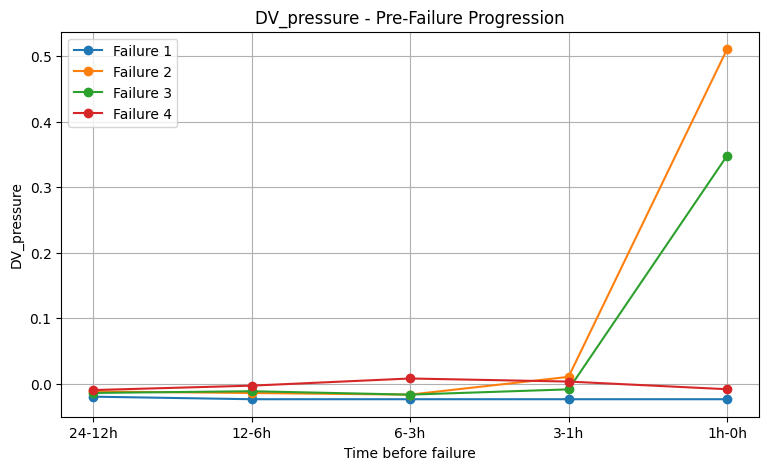

In [13]:
# Plot pre-failure progression for selected sensors across all failures

selected_sensors = [
    "TP2",
    "H1",
    "Motor_current",
    "Oil_temperature",
    "DV_pressure"
]

band_order = [
    "24-12h",
    "12-6h",
    "6-3h",
    "3-1h",
    "1h-0h"
]

plot_df = band_df[
    band_df["sensor"].isin(selected_sensors)
].copy()

plot_df["band"] = pd.Categorical(
    plot_df["band"],
    categories=band_order,
    ordered=True
)

for sensor in selected_sensors:

    sensor_data = plot_df[
        plot_df["sensor"] == sensor
    ]

    plt.figure(figsize=(9, 5))

    for failure_id in sorted(
        sensor_data["failure_id"].unique()
    ):

        failure_data = sensor_data[
            sensor_data["failure_id"] == failure_id
        ].sort_values("band")

        plt.plot(
            failure_data["band"],
            failure_data["mean"],
            marker="o",
            label=f"Failure {failure_id}"
        )

    plt.title(f"{sensor} - Pre-Failure Progression")
    plt.xlabel("Time before failure")
    plt.ylabel(sensor)
    plt.legend()
    plt.grid(True)
    plt.show()
    

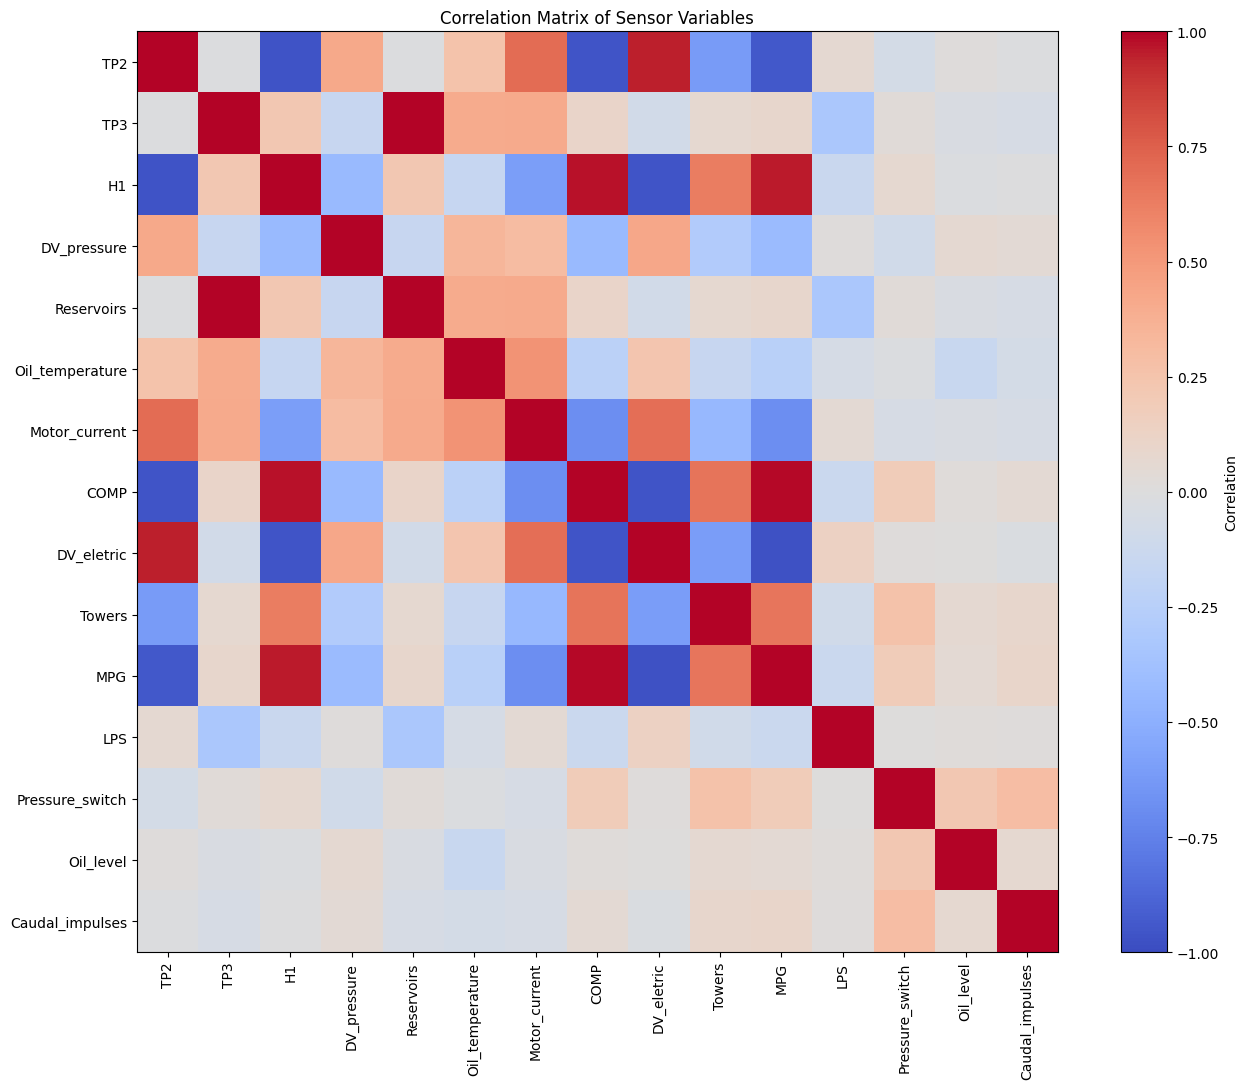

In [14]:
# Correlation matrix for all sensor variables

sensor_columns = [
    "TP2",
    "TP3",
    "H1",
    "DV_pressure",
    "Reservoirs",
    "Oil_temperature",
    "Motor_current",
    "COMP",
    "DV_eletric",
    "Towers",
    "MPG",
    "LPS",
    "Pressure_switch",
    "Oil_level",
    "Caudal_impulses"
]

correlation_matrix = df[sensor_columns].corr()

plt.figure(figsize=(14, 11))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(sensor_columns)),
    sensor_columns,
    rotation=90
)

plt.yticks(
    range(len(sensor_columns)),
    sensor_columns
)

plt.title("Correlation Matrix of Sensor Variables")

plt.tight_layout()
plt.show()

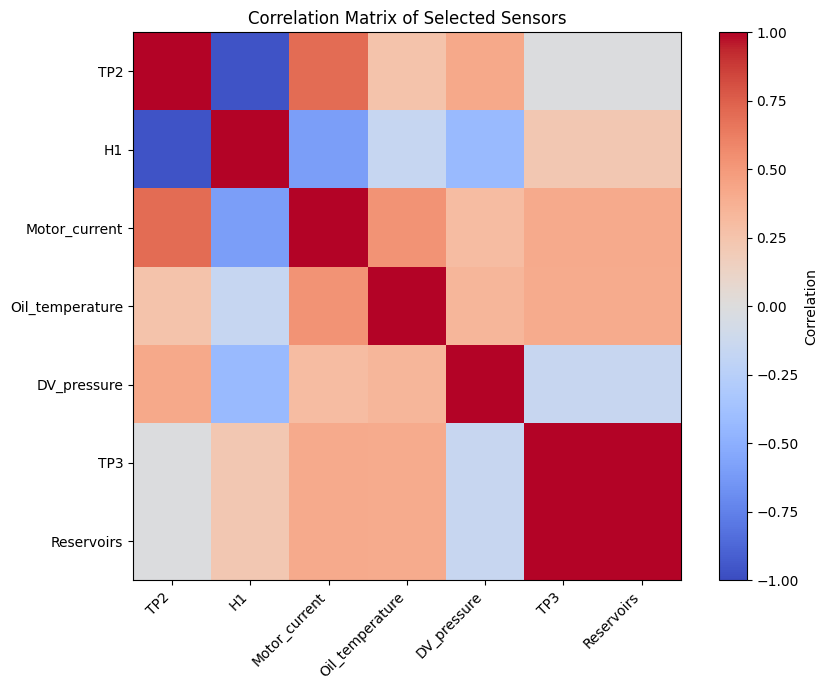

In [15]:
# Correlation matrix for selected sensors

selected_sensors = [
    "TP2",
    "H1",
    "Motor_current",
    "Oil_temperature",
    "DV_pressure",
    "TP3",
    "Reservoirs"
]

selected_correlation = df[selected_sensors].corr()

plt.figure(figsize=(9, 7))

plt.imshow(
    selected_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(selected_sensors)),
    selected_sensors,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(selected_sensors)),
    selected_sensors
)

plt.title("Correlation Matrix of Selected Sensors")

plt.tight_layout()
plt.show()

In [16]:
# Create a binary failure label
# 0 = normal / non-failure period
# 1 = documented failure period

df["failure"] = 0

for _, failure in failure_df.iterrows():

    mask = (
        (df["timestamp"] >= failure["start"]) &
        (df["timestamp"] <= failure["end"])
    )

    df.loc[mask, "failure"] = 1

print(df["failure"].value_counts())

df[["timestamp", "failure"]].head()

failure
0    1486994
1      29954
Name: count, dtype: int64


,timestamp,failure
0,2020-02-01 00:00:00,0
1,2020-02-01 00:00:10,0
2,2020-02-01 00:00:19,0
3,2020-02-01 00:00:29,0
4,2020-02-01 00:00:39,0


In [17]:
# Calculate the percentage of normal and failure observations

class_counts = df["failure"].value_counts()
class_percentages = df["failure"].value_counts(normalize=True) * 100

class_balance = pd.DataFrame({
    "observations": class_counts,
    "percentage": class_percentages
})

class_balance.index = ["Normal (0)", "Failure (1)"]

class_balance

,observations,percentage
Normal (0),1486994,98.025377
Failure (1),29954,1.974623


In [18]:
# Create a balanced dataset for failure-analysis modeling

failure_data = df[df["failure"] == 1].copy()
normal_data = df[df["failure"] == 0].copy()

# Sample normal observations to match the number of failure observations
normal_sample = normal_data.sample(
    n=len(failure_data),
    random_state=42
)

balanced_df = pd.concat(
    [failure_data, normal_sample],
    ignore_index=True
)

# Shuffle the dataset
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced dataset shape:", balanced_df.shape)
print("\nClass distribution:")
print(balanced_df["failure"].value_counts())

print("\nClass percentages:")
print(balanced_df["failure"].value_counts(normalize=True) * 100)

Balanced dataset shape: (59908, 18)

Class distribution:
failure
0    29954
1    29954
Name: count, dtype: int64

Class percentages:
failure
0    50.0
1    50.0
Name: proportion, dtype: float64


In [19]:
# Select the primary sensor variables for modeling

model_features = [
    "TP2",
    "H1",
    "Motor_current",
    "Oil_temperature",
    "DV_pressure"
]

X = balanced_df[model_features].copy()
y = balanced_df["failure"].copy()

print("Selected features:")
print(model_features)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Selected features:
['TP2', 'H1', 'Motor_current', 'Oil_temperature', 'DV_pressure']

Feature matrix shape: (59908, 5)
Target shape: (59908,)


,TP2,H1,Motor_current,Oil_temperature,DV_pressure
0,0.004,10.144,4.0975,57.050,0.000
1,-0.010,8.338,0.0350,59.000,-0.014
2,8.954,-0.008,5.6600,74.050,2.016
3,8.348,-0.008,5.6100,75.075,2.214
4,-0.012,9.036,0.0450,65.475,-0.020


In [20]:
from sklearn.model_selection import train_test_split

# Split the balanced dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (47926, 5)
Testing set: (11982, 5)

Training class distribution:
failure
0    23963
1    23963
Name: count, dtype: int64

Testing class distribution:
failure
1    5991
0    5991
Name: count, dtype: int64


In [21]:
from sklearn.preprocessing import StandardScaler

# Standardize the sensor variables
# Fit only on training data to avoid data leakage

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nFirst 5 scaled training observations:")
print(X_train_scaled[:5])

Scaled training shape: (47926, 5)
Scaled testing shape: (11982, 5)

First 5 scaled training observations:
[[-1.12588936  1.06715338 -1.53098827 -0.73978345 -0.94738432]
 [-1.12588936  1.19192452  0.03911184  0.0132235  -0.94738432]
 [ 0.59309804 -0.86881173  0.61109165  0.82999314  0.53484807]
 [ 0.40568602 -0.86881173  0.54799804  0.82999314  0.6240198 ]
 [-1.12685292  1.3564972   0.02566566  0.44438071 -0.94936591]]


In [22]:
from sklearn.linear_model import LogisticRegression

# Create baseline Logistic Regression model
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
baseline_model.fit(X_train_scaled, y_train)

# Generate predictions on test data
y_pred = baseline_model.predict(X_test_scaled)

print("Baseline Logistic Regression model trained successfully.")
print("Number of test predictions:", len(y_pred))

Baseline Logistic Regression model trained successfully.
Number of test predictions: 11982


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Baseline Logistic Regression Performance")
print("----------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Baseline Logistic Regression Performance
----------------------------------------
Accuracy : 0.9821
Precision: 0.9722
Recall   : 0.9925
F1-score : 0.9822

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5991
           1       0.97      0.99      0.98      5991

    accuracy                           0.98     11982
   macro avg       0.98      0.98      0.98     11982
weighted avg       0.98      0.98      0.98     11982

Confusion Matrix:
[[5821  170]
 [  45 5946]]


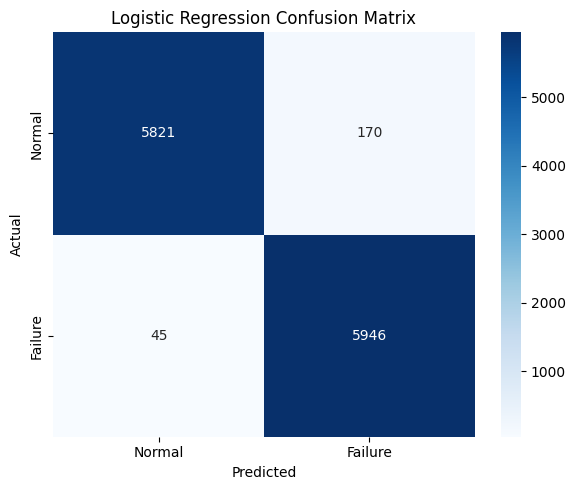

In [25]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Failure"],
    yticklabels=["Normal", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [26]:
coefficient_df = pd.DataFrame({
    "sensor": model_features,
    "coefficient": baseline_model.coef_[0]
})

coefficient_df["absolute_coefficient"] = coefficient_df["coefficient"].abs()

coefficient_df = coefficient_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

coefficient_df

,sensor,coefficient,absolute_coefficient
1,H1,-3.506114,3.506114
3,Oil_temperature,2.953001,2.953001
4,DV_pressure,2.497276,2.497276
0,TP2,-2.099889,2.099889
2,Motor_current,-1.158037,1.158037


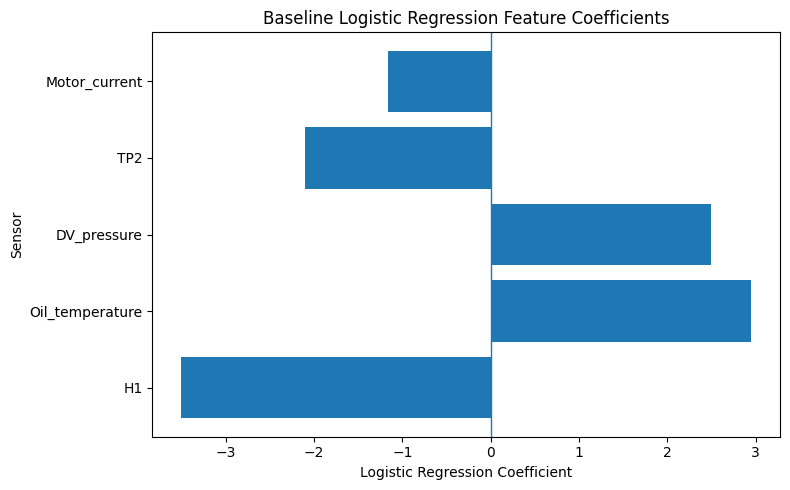

In [27]:
plt.figure(figsize=(8, 5))

plt.barh(
    coefficient_df["sensor"],
    coefficient_df["coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Sensor")
plt.title("Baseline Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [28]:
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_score": [f1]
})

baseline_results

,Model,Accuracy,Precision,Recall,F1_score
0,Logistic Regression,0.982056,0.972204,0.992489,0.982242


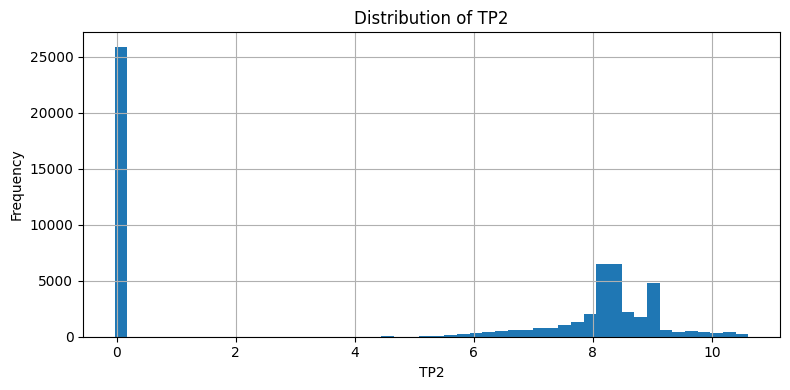

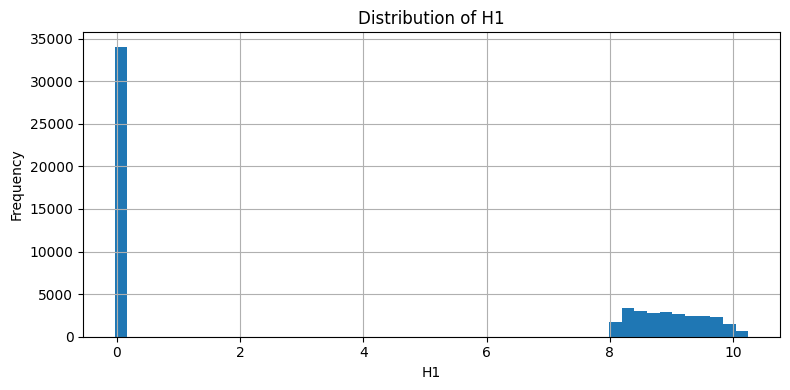

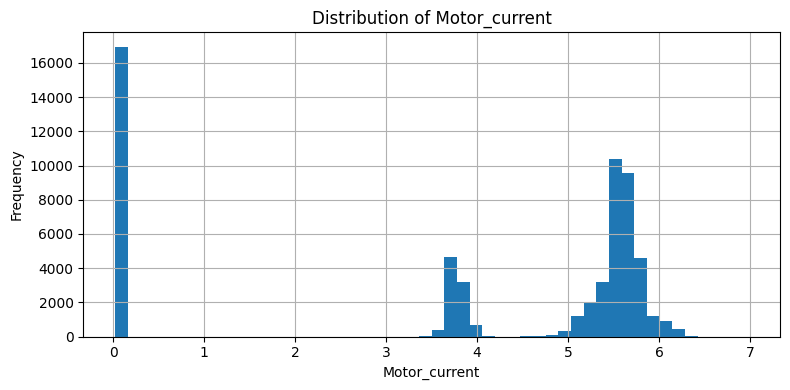

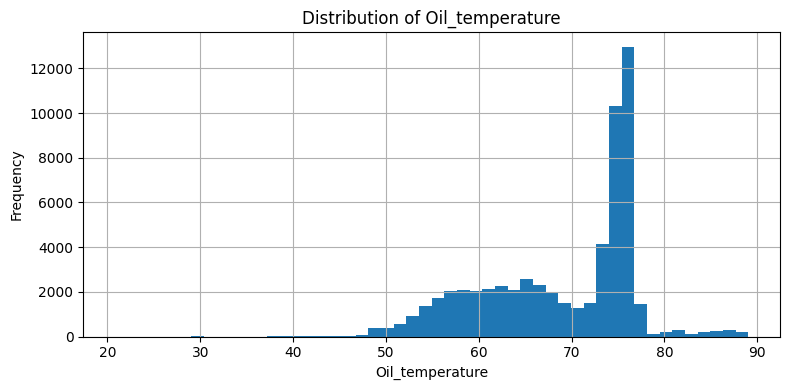

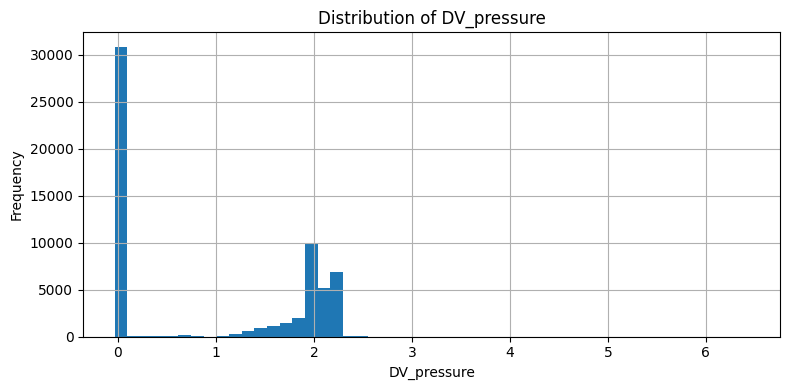

In [29]:
for sensor in model_features:
    plt.figure(figsize=(8, 4))
    
    plt.hist(
        balanced_df[sensor],
        bins=50
    )
    
    plt.title(f"Distribution of {sensor}")
    plt.xlabel(sensor)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()